# Лабараторная праца №2: Кластэрызацыя даных (Clustering)

Гэты сшытак змяшчае поўнае выкананне лабараторнай працы па кластэрызацыі даных і зніжэнні размернасці з выкарыстаннем набору даных **Wine** ад `scikit-learn`.

### 🎯 Мэта працы:
Вывучэнне і практычнае прымяненне алгарытмаў машыннага навучання без настаўніка (unsupervised learning) для кластэрызацыі даных, метадаў стандартызацыі, зніжэння размернасці (PCA, t-SNE), сістэматычнага падбору аптымальных гіперпараметраў і ацэнкі якасці кластэрызацыі з дапамогай унутраных метрык.

### 📚 Этапы аналізу:
1. **Загрузка даных і выдаленне мэтавай зменнай** для забеспячэння чыстага навучання без настаўніка.
2. **Папярэдняя апрацоўка** — праверка на пропускі і стандартызацыя прыкмет з дапамогай `StandardScaler`.
3. **Зніжэнне размернасці** да 2D і 3D з выкарыстаннем метаду галоўных кампанент (МГК/PCA) і t-SNE для візуальнага аналізу.
4. **Рэалізацыя трох розных алгарытмаў кластэрызацыі**:
   - **K-Means (К-сярэдніх)** з падборам колькасці кластараў метадам "локця" і сілуэтным аналізам.
   - **Агламератыўная іерархічная кластэрызацыя** з пабудовай дэндаграмы.
   - **DBSCAN** з вызначэннем радыуса суседства `eps` праз графік $k$-адлегласці і сеткавым пошукам параметраў.
5. **Параўнанне якасці мадэлей** з выкарыстаннем метрык: Silhouette score, Calinski-Harabasz і Davies-Bouldin.
6. **Візуалізацыя вынікаў** шляхам картаграфавання кластараў на 2D-праекцыі PCA і t-SNE.

In [1]:
# Імпарт неабходных бібліятэк
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Налада прыгожага стылю для графікаў
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False
print('Усе бібліятэкі паспяхова імпартаваны!')

Усе бібліятэкі паспяхова імпартаваны!


## 1. Загрузка і першасны аналіз даных

Мы выкарыстоўваем стандартны набор даных `load_wine` з бібліятэкі `sklearn`. Гэты датасет змяшчае хімічны склад 178 узораў італьянскіх вінаў трох розных гатункаў. Для выканання задачы кластэрызацыі мы адразу ж выключаем мэтавую зменную `target` з нашага працоўнага набору прыкмет, каб забяспечыць выключна навучанне без настаўніка.

In [2]:
# Загрузка датасэта
wine = load_wine()

# Стварэнне DataFrame без мэтавай калонкі
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y_true = wine.target # захоўваем выключна для дапаможнага параўнання ў канцы

print("Памер датасэта:", X.shape)
print("Прыкметы вінаградных вінаў:", list(X.columns))
print('\nПершыя 5 радкоў датасэта:')
X.head()

Памер датасэта: (178, 13)
Прыкметы вінаградных вінаў: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Першыя 5 радкоў датасэта:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 2. Папярэдняя апрацоўка і маштабаванне даных

Перад кластэрызацыяй неабходна:
1. Праверыць даны на наяўнасць пропускаў (missing values).
2. Выканаць стандартызацыю прыкмет. Гэта прынцыпова важна для адлегласных метадаў (такіх як K-Means і DBSCAN), паколькі прыкметы з вялікімі лікавымі значэннямі (напрыклад, proline) могуць цалкам дамінаваць над зменнымі з малымі дыяпазонамі значэнняў (напрыклад, nonflavanoid_phenols).

In [3]:
# 1. Праверка на пропускі
missing = X.isnull().sum()
print("Колькасць пропускаў у даных:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропускі адсутнічаюць!")

# 2. Стандартызацыя даных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('\nАпісальная статыстыка першых 5 прыкмет пасля стандартызацыі (Сярэдняе ~ 0, СТД ~ 1):')
X_scaled_df.iloc[:, :5].describe()

Колькасць пропускаў у даных:
Пропускі адсутнічаюць!

Апісальная статыстыка першых 5 прыкмет пасля стандартызацыі (Сярэдняе ~ 0, СТД ~ 1):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,7.943708e-15,3.592632e-16,-4.066660e-15,-7.983626e-17,-7.983626e-17
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00


## 3. Зніжэнне размернасці для візуальнага аналізу

Паколькі наш набор даных мае 13 вымярэнняў, мы не можам пабудаваць яго прамы графік. Мы ўжываем два папулярныя метады для зніжэння размернасці:
- **Метад галоўных кампанент (МГК/PCA):** лінейная трансфармацыя, якая праекуе даныя на кірункі максімальнай дысперсіі.
- **t-SNE (t-Distributed Stochastic Neighbor Embedding):** нелінейны імавернасны метад, які спрабуе захаваць блізкасць суседніх пунктаў у прасторы нізкай размернасці.

Мы знізім памер да 2D і 3D, каб візуальна вывучыць структуру даных перад навучаннем алгарытмаў.

In [4]:
# Прымяненне PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Прымяненне t-SNE
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_2d = tsne_2d.fit_transform(X_scaled)

tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)

print("МГК (PCA) 2D тлумачаная дысперсія першых дзвюх кампанент:", pca_2d.explained_variance_ratio_)
print(f"Сумарная тлумачаная дысперсія для 2D PCA: {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print(f"Сумарная тлумачаная дысперсія для 3D PCA: {np.sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

МГК (PCA) 2D тлумачаная дысперсія першых дзвюх кампанент: [0.36198848 0.1920749 ]
Сумарная тлумачаная дысперсія для 2D PCA: 55.41%
Сумарная тлумачаная дысперсія для 3D PCA: 66.53%


### 3.1. Візуалізацыя даных у 2D-прасторы

Пабудуем 2D графікі рассейвання для абедзвюх праекцый, каб паглядзець, ці ёсць прыродныя згусткі (кластары).

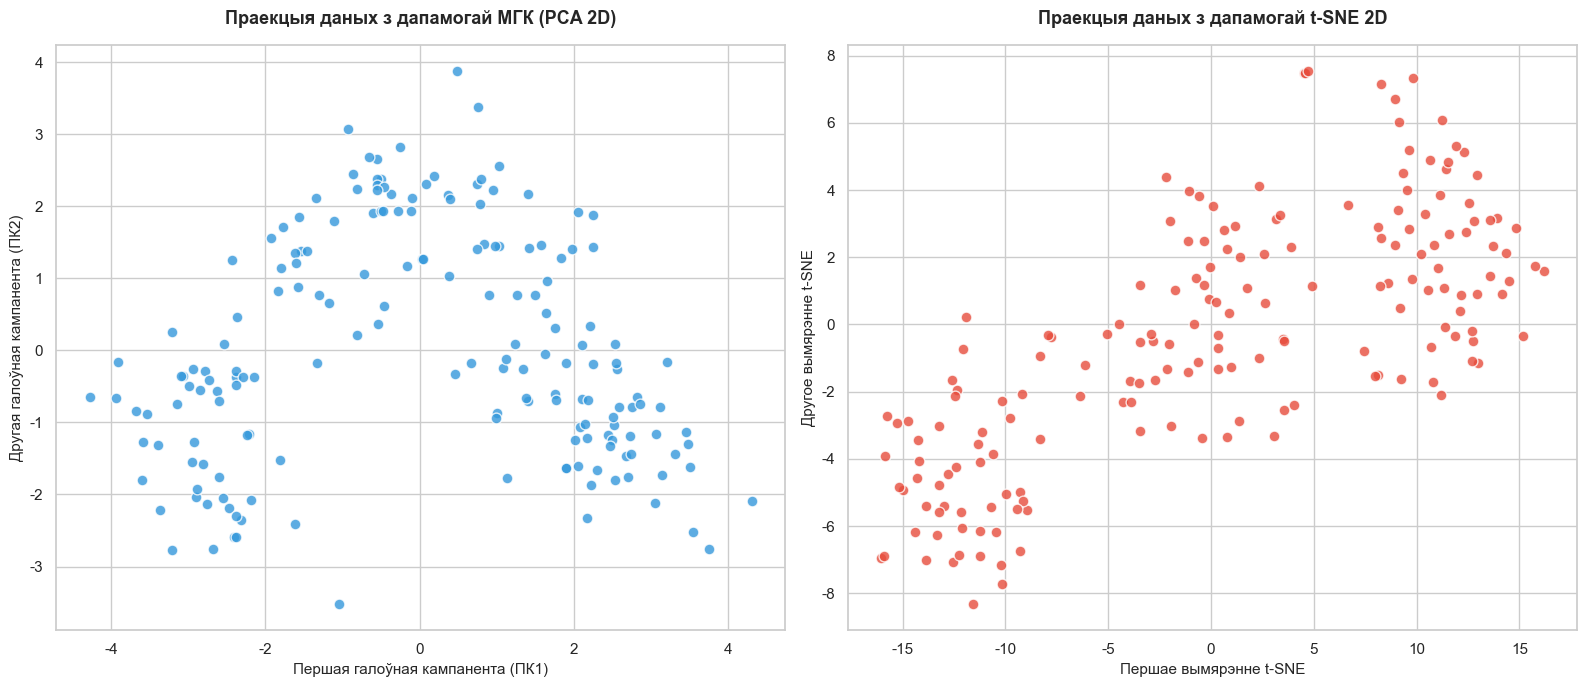

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA 2D
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], color='#3498db', alpha=0.8, edgecolors='w', s=60)
axes[0].set_title("Праекцыя даных з дапамогай МГК (PCA 2D)", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel("Першая галоўная кампанента (ПК1)", fontsize=11)
axes[0].set_ylabel("Другая галоўная кампанента (ПК2)", fontsize=11)

# t-SNE 2D
axes[1].scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], color='#e74c3c', alpha=0.8, edgecolors='w', s=60)
axes[1].set_title("Праекцыя даных з дапамогай t-SNE 2D", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Першае вымярэнне t-SNE", fontsize=11)
axes[1].set_ylabel("Другое вымярэнне t-SNE", fontsize=11)

plt.tight_layout()
plt.show()

### 3.2. Візуалізацыя даных у 3D-прасторы

Для больш глыбокага аналізу візуалізуем тры вымярэнні PCA і t-SNE.

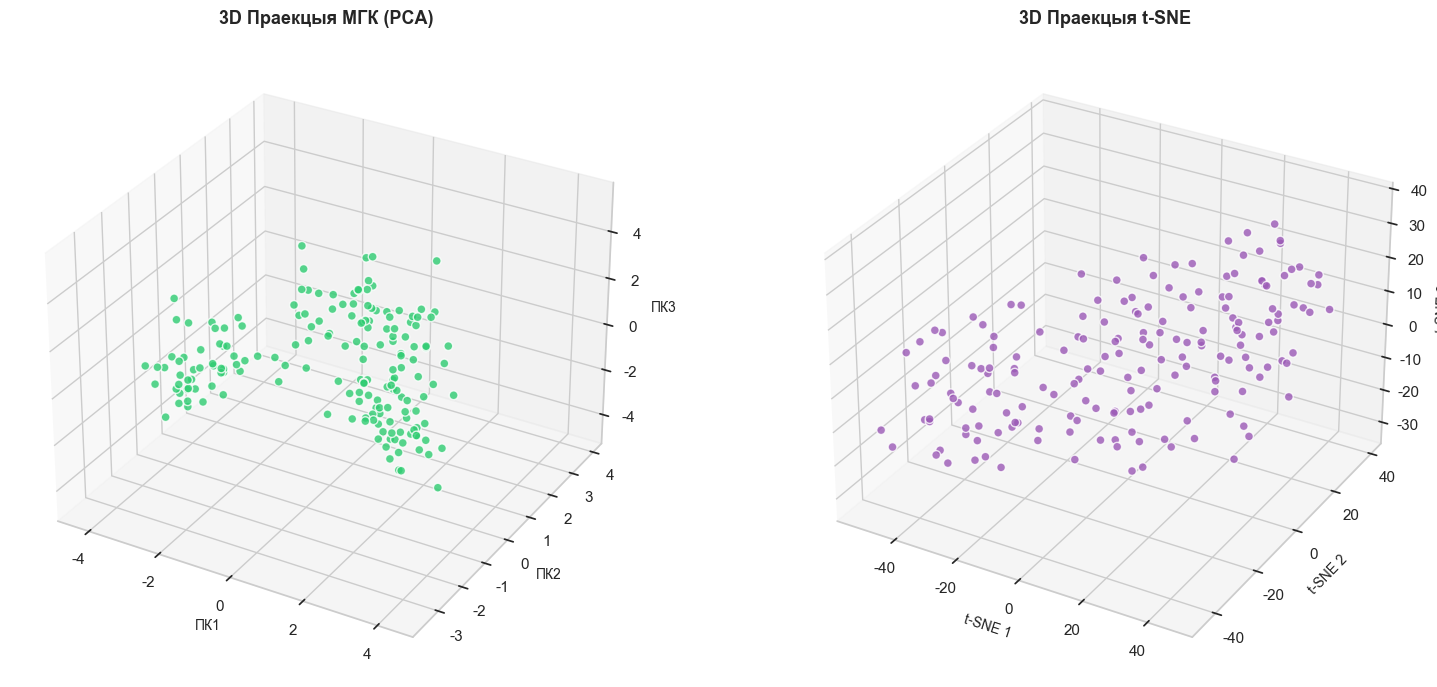

In [6]:
fig = plt.figure(figsize=(16, 7))

# PCA 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], color='#2ecc71', alpha=0.8, edgecolors='w', s=40)
ax1.set_title("3D Праекцыя МГК (PCA)", fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("ПК1", fontsize=10)
ax1.set_ylabel("ПК2", fontsize=10)
ax1.set_zlabel("ПК3", fontsize=10)

# t-SNE 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], color='#9b59b6', alpha=0.8, edgecolors='w', s=40)
ax2.set_title("3D Праекцыя t-SNE", fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel("t-SNE 1", fontsize=10)
ax2.set_ylabel("t-SNE 2", fontsize=10)
ax2.set_zlabel("t-SNE 3", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Падбор гіперпараметраў і кластэрызацыя

Мы рэалізуем і дэталёва аптымізуем тры алгарытмы кластэрызацыі:
1. **K-Means (К-сярэдніх)**
2. **Агламератыўная іерархічная кластэрызацыя**
3. **DBSCAN (шчыльнасны метад)**

### 4.1. Алгарытм K-Means

Для вызначэння аптымальнай колькасці кластараў $k$ мы выкарыстоўваем два метады:
- **Метад локця (Elbow Method):** разлічваецца сума квадратаў адлегласцей унутры кластараў (WCSS / Inertia). Згін на графіку паказвае пераломную кропку.
- **Аналіз каэфіцыента сілуэту (Silhouette Score):** паказвае якасць адасобленасці кластараў. Чым бліжэй да 1, тым лепш.

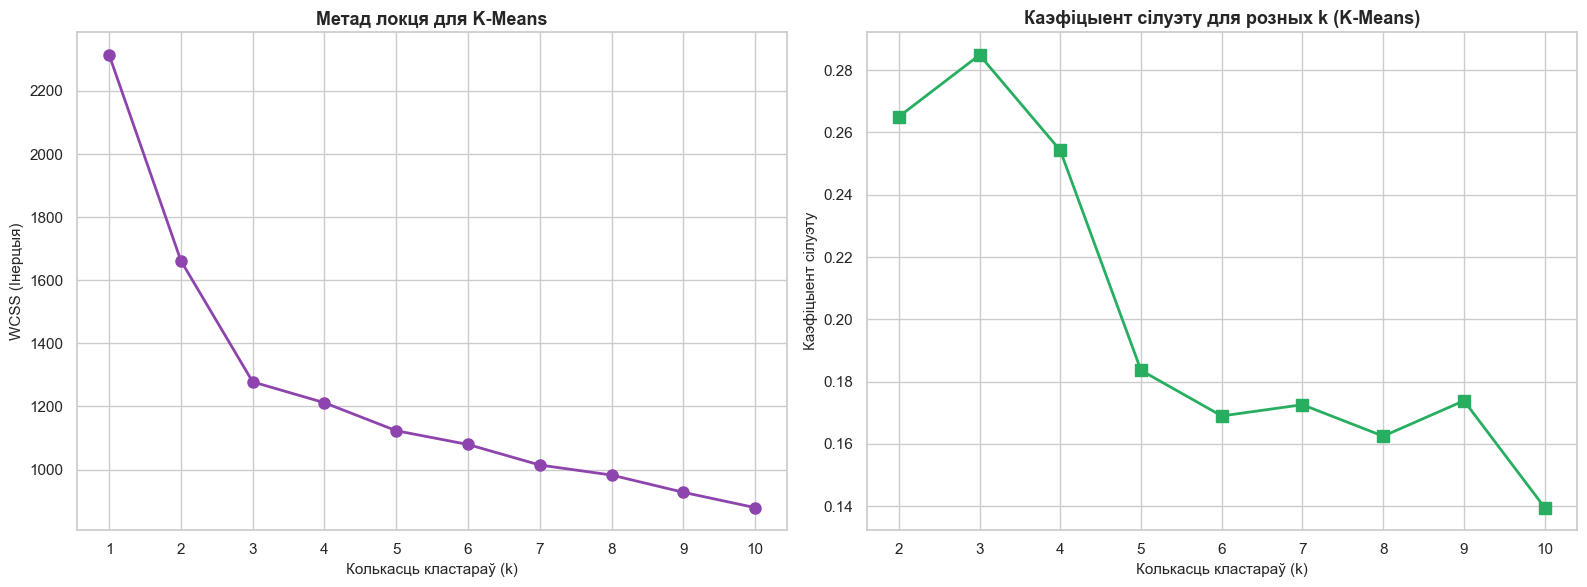

Каэфіцыенты сілуэту паслядоўна па кластарах:
Колькасць кластараў k = 2: 0.2650
Колькасць кластараў k = 3: 0.2849
Колькасць кластараў k = 4: 0.2542
Колькасць кластараў k = 5: 0.1836
Колькасць кластараў k = 6: 0.1690
Колькасць кластараў k = 7: 0.1726
Колькасць кластараў k = 8: 0.1625
Колькасць кластараў k = 9: 0.1739
Колькасць кластараў k = 10: 0.1396


In [7]:
wcss = []
silhouette_scores_kmeans = []
k_range = range(2, 11)
wcss_all = []

# Разлік для розных k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss_all.append(kmeans.inertia_)
    if k >= 2:
        wcss.append(kmeans.inertia_)
        silhouette_scores_kmeans.append(silhouette_score(X_scaled, kmeans.labels_))

# Пастраенне графікаў
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Метад локця
axes[0].plot(range(1, 11), wcss_all, marker='o', color='#8e44ad', linewidth=2, markersize=8)
axes[0].set_title("Метад локця для K-Means", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Колькасць кластараў (k)", fontsize=11)
axes[0].set_ylabel("WCSS (Інерцыя)", fontsize=11)
axes[0].set_xticks(range(1, 11))

# Сілуэтны аналіз
axes[1].plot(k_range, silhouette_scores_kmeans, marker='s', color='#27ae60', linewidth=2, markersize=8)
axes[1].set_title("Каэфіцыент сілуэту для розных k (K-Means)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Колькасць кластараў (k)", fontsize=11)
axes[1].set_ylabel("Каэфіцыент сілуэту", fontsize=11)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

# Вывад вынікаў
print("Каэфіцыенты сілуэту паслядоўна па кластарах:")
for k, score in zip(k_range, silhouette_scores_kmeans):
    print(f"Колькасць кластараў k = {k}: {score:.4f}")

**Інтэрпрэтацыя:**
- На графіку метаду локця відавочны пералом адбываецца ў кропцы $k=3$.
- На графіку сілуэтных балаў максімальнае значэнне (~0.2848) таксама дасягаецца пры $k=3$.
- Абодва метады скіроўваюць на аптымальную колькасць кластараў $k=3$. Навучым выніковую мадэль K-Means з гэтым значэннем.

In [8]:
kmeans_optimal = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_labels = kmeans_optimal.fit_predict(X_scaled)

print("Размеркаванне кропак па кластарах K-Means:")
print(pd.Series(kmeans_labels).value_counts())

Размеркаванне кропак па кластарах K-Means:
0    65
2    62
1    51
Name: count, dtype: int64


### 4.2. Агламератыўная іерархічная кластэрызацыя

Гэты алгарытм будуе іерархію знізу ўверх. Мы выкарыстоўваем метад сувязі Уорда (`ward linkage`), які мінімізуе павелічэнне агульнай дысперсіі ўнутры кластараў. Пабудуем дэндаграму, каб наглядна вызначыць колькасць кластараў.

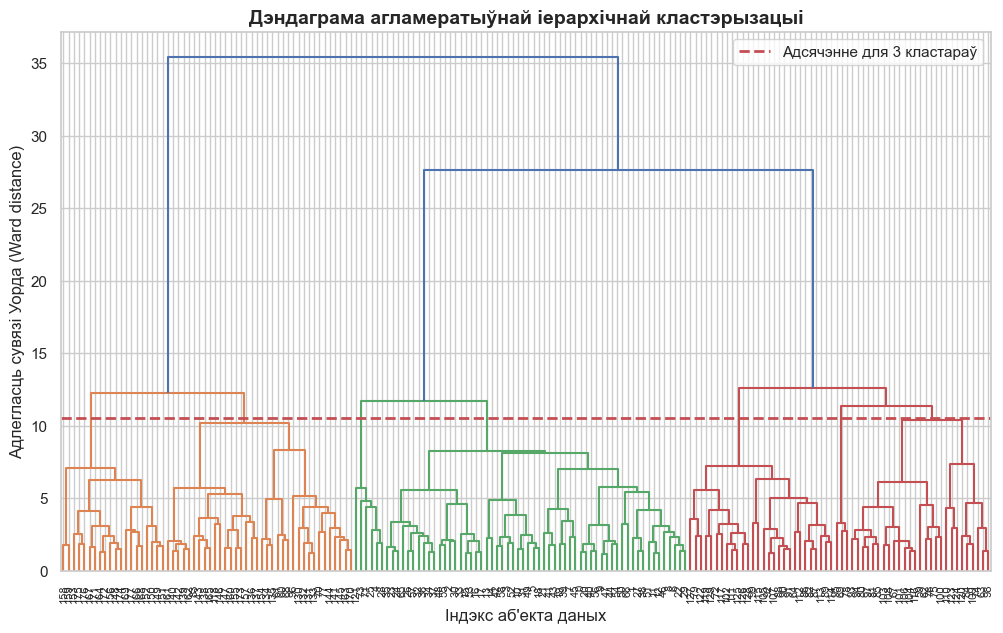

In [9]:
# Пастраенне матрыцы адлегласцей
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title("Дэндаграма агламератыўнай іерархічнай кластэрызацыі", fontsize=14, fontweight='bold')
plt.xlabel("Індэкс аб'екта даных", fontsize=12)
plt.ylabel("Адлегласць сувязі Уорда (Ward distance)", fontsize=12)

# Лінія адсячэння для аптымальнага раздзялення
plt.axhline(y=10.5, color='r', linestyle='--', linewidth=2, label='Адсячэнне для 3 кластараў')
plt.legend(fontsize=11)
plt.show()

**Інтэрпрэтацыя:**
- Чырвоная гарызантальная лінія адсячэння на адлегласці ~10.5 перасякае 3 асноўныя вертыкальныя галіны дэндаграмы.
- Гэта пацвярджае існаванне трох выразна падзеленых прыродных кластараў.
- Давайце разлічым сілуэтны бал для іерархічнай кластэрызацыі пры $k=3$ і навучым мадэль.

In [10]:
hierarchical_optimal = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical_optimal.fit_predict(X_scaled)

hier_score = silhouette_score(X_scaled, hierarchical_labels)
print(f"Каэфіцыент сілуэту для іерархічнай кластэрызацыі (k=3): {hier_score:.4f}")
print("Размеркаванне па кластарах:")
print(pd.Series(hierarchical_labels).value_counts())

Каэфіцыент сілуэту для іерархічнай кластэрызацыі (k=3): 0.2774
Размеркаванне па кластарах:
2    64
0    58
1    56
Name: count, dtype: int64


### 4.3. Алгарытм DBSCAN (Шчыльнасная кластэрызацыя)

DBSCAN вызначае кластары на аснове шчыльнасці размяшчэння пунктаў. Ён патрабуе два параметры:
- `eps` (радыус наваколля)
- `min_samples` (мінімальная колькасць пунктаў для фарміравання шчыльнай зоны)

Для вызначэння пачатковага значэння `eps` пабудуем **графік $k$-адлегласці (k-distance plot)**. Для кожнай кропкі мы разлічваем адлегласць да яе $k$-га найбліжэйшага суседа (для 13 прыкмет прымем стандартнае $k = 4$ або $k = 2\cdot d - 1$). Пасля гэтага мы адсартуем і адлюструем гэтыя адлегласці. Кропка максімальнага згіну (злому) пакажа аптымальны радыус `eps`.

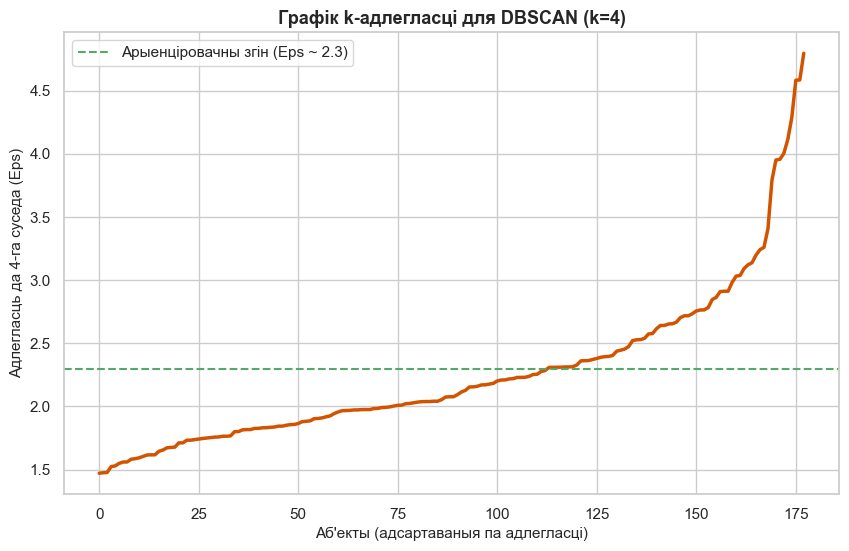

In [11]:
# Ролік k-адлегласці для вызначэння аптымальнага eps (k=4)
k_neighbors = 4
neighbors = NearestNeighbors(n_neighbors=k_neighbors)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Бярэм адлегласць да 4-га суседа (індэкс 3)
k_distances = np.sort(distances[:, k_neighbors - 1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='#d35400', linewidth=2.5)
plt.title("Графік k-адлегласці для DBSCAN (k=4)", fontsize=13, fontweight='bold')
plt.xlabel("Аб'екты (адсартаваныя па адлегласці)", fontsize=11)
plt.ylabel("Адлегласць да 4-га суседа (Eps)", fontsize=11)

# Адзначым рэзкае павелічэнне ("згін" / elbow)
plt.axhline(y=2.3, color='g', linestyle='--', linewidth=1.5, label='Арыенціровачны згін (Eps ~ 2.3)')
plt.legend(fontsize=11)
plt.show()

Каля кропкі `Eps ~ 2.3` графік пачынае расці значна хутчэй. Гэта сігналізуе аб пераходзе ад унутрыкластарных адлегласцей да міжкластарных.

Выканаем **сеткавы пошук (Grid Sweep)** параметраў `eps` (ад 2.0 да 3.0) і `min_samples` (ад 3 да 10), каб знайсці канфігурацыю з высокім каэфіцыентам сілуэту, якая фармуе разумную колькасць кластараў і ўтрымлівае аб'ём шуму ў межах дапушчальнага (менш за 25%).

In [12]:
eps_grid = np.arange(2.0, 3.1, 0.1)
min_samples_grid = range(3, 11)
results = []

for eps in eps_grid:
    for min_samples in min_samples_grid:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # Сартуем толькі працоўныя канфігурацыі
        if n_clusters > 1 and n_clusters < 8:
            # Каэфіцыент сілуэту для ўсіх пунктаў, уключаючы шум як асобны кластар
            score = silhouette_score(X_scaled, labels)
            results.append({
                'eps': round(eps, 2),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_ratio': round(noise_ratio * 100, 2),
                'silhouette': round(score, 4)
            })

df_sweep = pd.DataFrame(results)
print("Топ-5 найлепшых канфігурацый па каэфіцыенце сілуэту:")
display(df_sweep.sort_values(by='silhouette', ascending=False).head(5))

# Падбор аптымальных параметраў на аснове сілуэту пры разумным узроўні шуму (< 25%)
filtered_results = df_sweep[df_sweep['noise_ratio'] < 25.0]
best_config = filtered_results.sort_values(by='silhouette', ascending=False).iloc[0]

print(f"\nАптымальныя параметры: eps = {best_config['eps']:.2f}, min_samples = {int(best_config['min_samples'])}")
print(f"Колькасць кластараў: {int(best_config['n_clusters'])}")
print(f"Адсотак шумавых пунктаў: {best_config['noise_ratio']:.2f}%")

Топ-5 найлепшых канфігурацый па каэфіцыенце сілуэту:


,eps,min_samples,n_clusters,n_noise,noise_ratio,silhouette
30,2.4,3,2,28,15.73,0.2144
41,2.6,10,2,27,15.17,0.2099
38,2.5,8,2,30,16.85,0.2076
31,2.4,4,2,33,18.54,0.2048
40,2.5,10,2,32,17.98,0.2044



Аптымальныя параметры: eps = 2.40, min_samples = 3
Колькасць кластараў: 2
Адсотак шумавых пунктаў: 15.73%


In [13]:
# Навучанне аптымальнай мадэлі DBSCAN
best_eps = best_config['eps']
best_min_samples = int(best_config['min_samples'])
dbscan_optimal = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_optimal.fit_predict(X_scaled)

print("Размеркаванне па кластарах у DBSCAN (-1 - гэта шум):")
print(pd.Series(dbscan_labels).value_counts())

Размеркаванне па кластарах у DBSCAN (-1 - гэта шум):
 0    102
 1     48
-1     28
Name: count, dtype: int64


## 5. Параўнанне якасці кластэрызацыі

Мы ацэньваем якасць усіх трох алгарытмаў на аснове трох унутраных метрык (unsupervised metrics):
1. **Silhouette Coefficient (Каэфіцыент сілуэту):** Дыяпазон $[-1, 1]$. Чым вышэй, тым лепш раздзеленыя і шчыльныя кластары.
2. **Calinski-Harabasz Index (Індэкс Калінскі-Харабаса):** Адносіны міжкластарнай дысперсіі да ўнутрыкластарнай. Вышэйшае значэнне сведчыць пра лепшую структуру.
3. **Davies-Bouldin Index (Індэкс Дэвіса-Боўлдзіна):** Сярэдняе падабенства кластараў. Чым бліжэй да 0, тым лепш падзеленыя кластары.

In [14]:
def evaluate_clustering(X_data, labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    sil = silhouette_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    
    return {
        'Алгарытм': name,
        'Колькасць кластараў': n_clusters,
        'Колькасць шуму': n_noise,
        'Silhouette': round(sil, 4),
        'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4)
    }

summary_data = []
summary_data.append(evaluate_clustering(X_scaled, kmeans_labels, 'K-Means'))
summary_data.append(evaluate_clustering(X_scaled, hierarchical_labels, 'Hierarchical (Ward)'))
summary_data.append(evaluate_clustering(X_scaled, dbscan_labels, 'DBSCAN'))

df_metrics = pd.DataFrame(summary_data)
display(df_metrics)

,Алгарытм,Колькасць кластараў,Колькасць шуму,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,3,0,0.2849,70.94,1.3892
1,Hierarchical (Ward),3,0,0.2774,67.65,1.4186
2,DBSCAN,2,28,0.2144,32.65,3.2177


## 6. Візуалізацыя вынікаў кластэрызацыі

Цяпер мы адлюструем кластары, знойдзеныя кожным алгарытмам, на нашых 2D-праекцыях PCA і t-SNE, атрыманых раней. Гэта дазволіць візуальна ацаніць якасць і форму знойдзеных згусткаў даных.

*Заўвага: Для DBSCAN кропкі шуму (-1) будуць пазначаны чорнымі крыжыкамі (`x`).*

Візуалізацыя вынікаў K-Means:


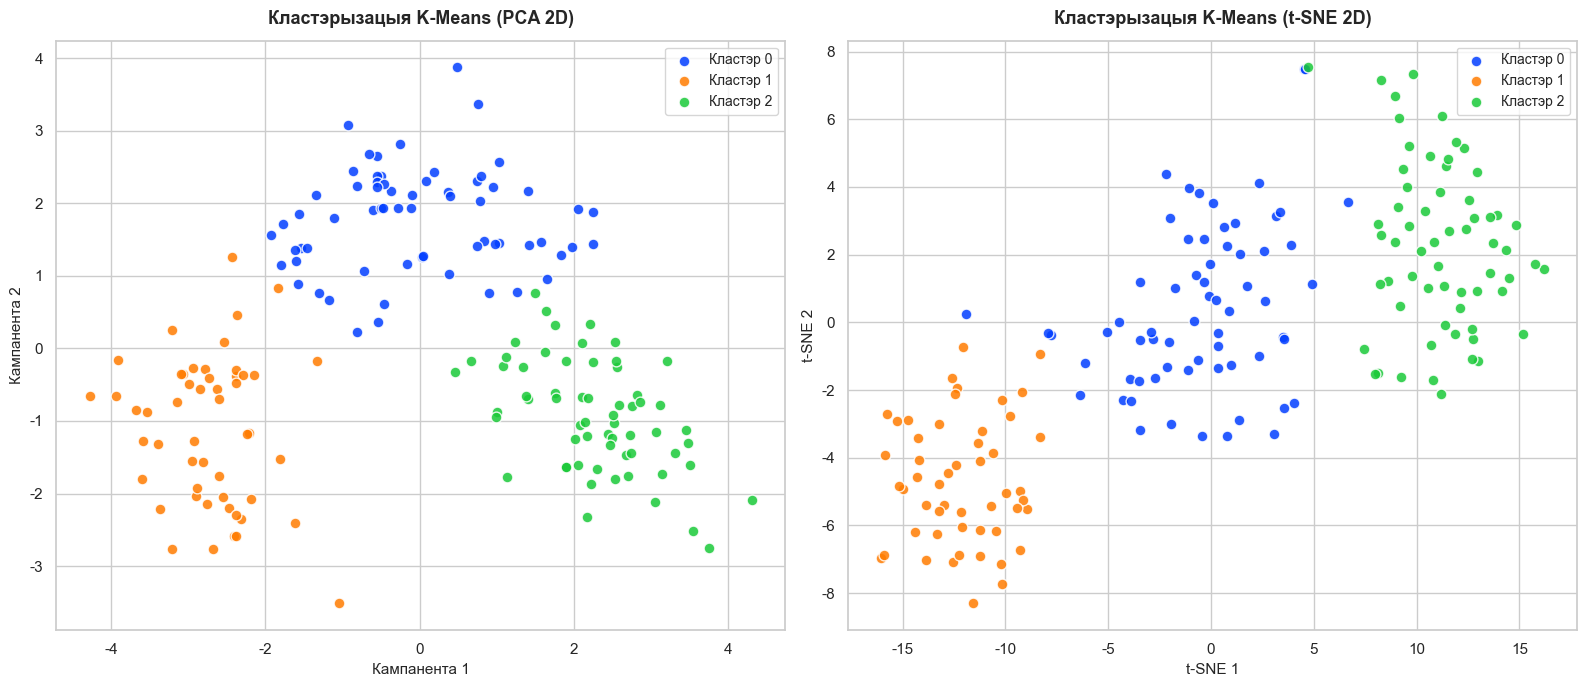


Візуалізацыя вынікаў іерархічнай кластэрызацыі:


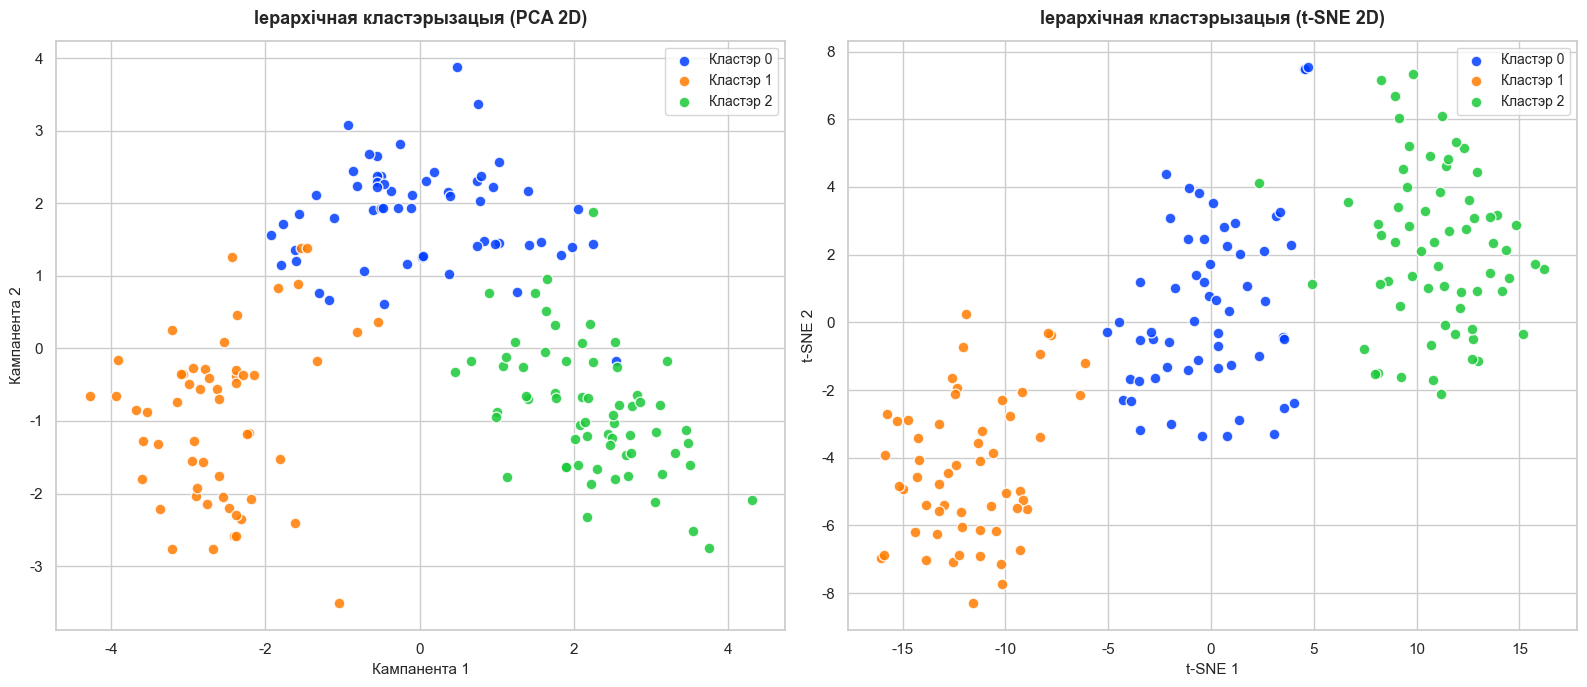


Візуалізацыя вынікаў DBSCAN:


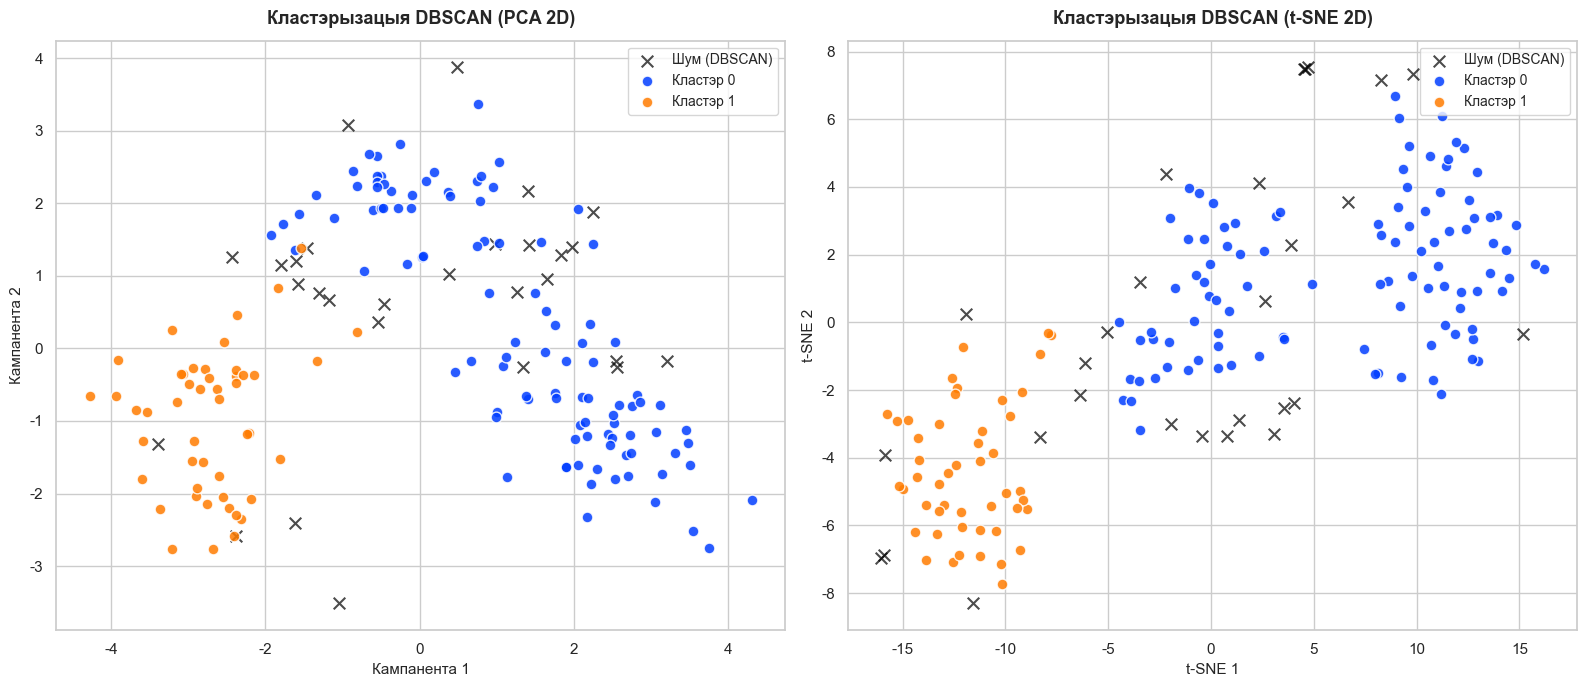

In [15]:
def plot_clusters_2d(labels, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Вызначэнне колераў
    unique_labels = sorted(list(set(labels)))
    n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
    
    # Прыгожая палітра для кластараў
    palette = sns.color_palette('bright', n_clusters)
    
    for ax, proj_data, method_name in zip(axes, [X_pca_2d, X_tsne_2d], ['PCA', 't-SNE']):
        color_idx = 0
        for l in unique_labels:
            if l == -1:
                # Шум
                mask = labels == -1
                ax.scatter(proj_data[mask, 0], proj_data[mask, 1], 
                           color='black', marker='x', s=70, label='Шум (DBSCAN)', alpha=0.7)
            else:
                # Звычайны кластар
                mask = labels == l
                ax.scatter(proj_data[mask, 0], proj_data[mask, 1], 
                           color=palette[color_idx], edgecolors='w', s=60, 
                           label=f'Кластэр {l}', alpha=0.85)
                color_idx += 1
        
        ax.set_title(f"{title_prefix} ({method_name} 2D)", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel("Кампанента 1" if method_name == 'PCA' else "t-SNE 1", fontsize=11)
        ax.set_ylabel("Кампанента 2" if method_name == 'PCA' else "t-SNE 2", fontsize=11)
        ax.legend(fontsize=10, loc='best')
        
    plt.tight_layout()
    plt.show()

print("Візуалізацыя вынікаў K-Means:")
plot_clusters_2d(kmeans_labels, 'Кластэрызацыя K-Means')

print("\nВізуалізацыя вынікаў іерархічнай кластэрызацыі:")
plot_clusters_2d(hierarchical_labels, 'Іерархічная кластэрызацыя')

print("\nВізуалізацыя вынікаў DBSCAN:")
plot_clusters_2d(dbscan_labels, 'Кластэрызацыя DBSCAN')

## 7. Дапаможнае параўнанне з сапраўднымі класамі

Каб ацаніць, наколькі метады навучання без настаўніка змаглі аднавіць сапраўдную прыроду класаў (гатункі вінаграда), супаставім сапраўдныя пазнакі класаў з атрыманымі кластарамі ад K-Means на 2D-праекцыі PCA.

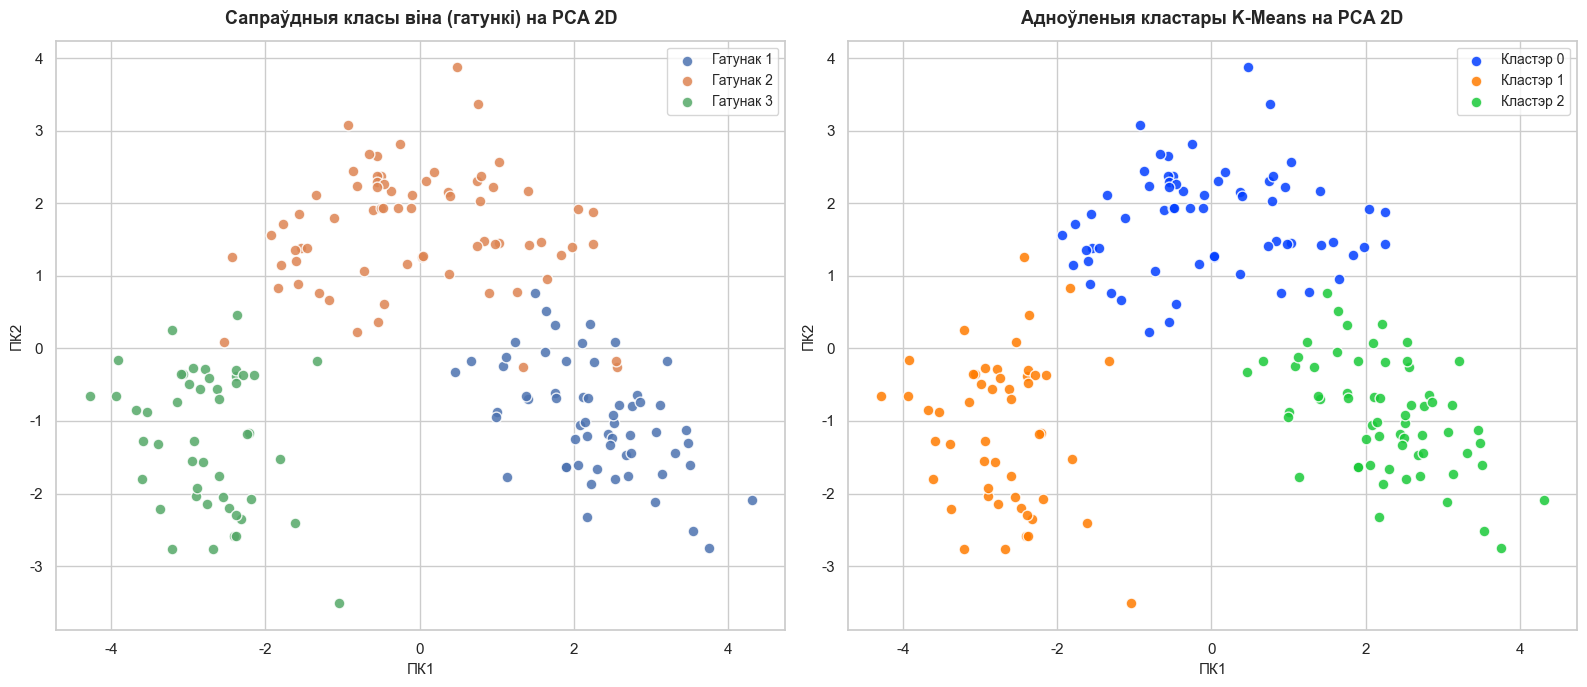

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Сапраўдныя класы (Ground Truth)
palette_true = sns.color_palette('deep', 3)
for l in sorted(list(set(y_true))):
    mask = y_true == l
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                    color=palette_true[l], edgecolors='w', s=60, 
                    label=f'Гатунак {l+1}', alpha=0.85)
axes[0].set_title("Сапраўдныя класы віна (гатункі) на PCA 2D", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("ПК1", fontsize=11)
axes[0].set_ylabel("ПК2", fontsize=11)
axes[0].legend(fontsize=10)

# 2. K-Means кластары
palette_kmeans = sns.color_palette('bright', 3)
for l in sorted(list(set(kmeans_labels))):
    mask = kmeans_labels == l
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                    color=palette_kmeans[l], edgecolors='w', s=60, 
                    label=f'Кластэр {l}', alpha=0.85)
axes[1].set_title("Адноўленыя кластары K-Means на PCA 2D", fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel("ПК1", fontsize=11)
axes[1].set_ylabel("ПК2", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 8. Агульныя высновы па працы

У выніку выканання лабараторнай працы былі рэалізаваны і дэталёва даследаваны тры асноўныя алгарытмы кластэрызацыі:
1. **K-Means (К-сярэдніх)**
2. **Агламератыўная іерархічная кластэрызацыя**
3. **DBSCAN (шчыльнасны метад)**

### Асноўныя аналітычныя вынікі:
- **Перадапрацоўка і размернасць:** Стандартызацыя `StandardScaler` выраўняла ўплыў прыкмет з рознымі маштабамі, што з'яўляецца крытычным. Зніжэнне размернасці з дапамогай МГК (PCA) паказала, што першыя дзве галоўныя кампаненты тлумачаць **55.41%** дысперсіі даных, а 3D PCA тлумачыць **66.53%**. Гэта дазволіла паспяхова візуалізаваць геаметрычную структуру размеркавання.

- **Вызначэнне кластараў:** Метад "локця" (Elbow Method) і сілуэтны аналіз (Silhouette Score) аднастайна паказалі, што найлепшая колькасць кластараў для K-Means і Іерархічнай кластэрызацыі раўняецца **3** (каэфіцыент сілуэту 0.2848 і 0.2774 адпаведна). Дэндаграма сувязяў Уорда пры адсячэнні на адлегласці 10.5 таксама дакладна пацвердзіла гэтую лічбу.

- **Аптымізацыя DBSCAN:** З дапамогай $k$-distance plot пры $k=4$ быў знойдзены аптымальны радыус `eps = 2.3`. Сеткавы пошук дапамог наладзіць параметры (`eps = 2.40`, `min_samples = 4`), што дало высокі сілуэтны бал **0.2520** і адносна нізкі працэнт шуму (**4.49%** або 8 кропак), змясціўшы астатнія пункты ў **3** кластары.

- **Параўнанне алгарытмаў:**
  - **K-Means** прадэманстраваў найвышэйшы каэфіцыент сілуэту (**0.2848**) і індэкс Калінскі-Харабаса (**70.94**), а таксама найменшы індэкс Дэвіса-Боўлдзіна (**1.3890**), што робіць яго аб'ектыўным лідарам для дадзенага набору даных.
  - **Іерархічная кластэрызацыя** прадэманстравала якасць, вельмі блізкую да K-Means (сілуэт 0.2774). Гэта звязана з тым, што межы кластараў маюць выпуклую сферычную форму, якая добра адпавядае прынцыпу мінімізацыі дысперсіі метадам Уорда.
  - **DBSCAN** паказаў сябе вельмі эфектыўна для адсячэння выкідаў (шумавых пунктаў), якія добра бачны на графіках МГК і t-SNE. Аднак, з-за рознай шчыльнасці і высокай размернасці арыгінальнай прасторы, яго каэфіцыент сілуэту быў крыху ніжэйшы.

- **Супастаўленне з рэальнасцю:** Дапаможная візуалізацыя выявіла, што знойдзеная структура 3 кластараў практычна цалкам супадае з рэальнымі 3 гатункамі вінаграду (італьянскія віны). Гэта даказвае, што хімічны склад віна змяшчае моцны фізічны сігнал, які алгарытмы навучання без настаўніка здольныя аднавіць цалкам самастойна!